In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import HDBSCAN
from tqdm import tqdm
from sklearn.metrics import silhouette_samples, silhouette_score
import colorsys

In [2]:
# HIPERPARÁMETROS
SIZE=100
SAMPLES=6

In [3]:
df_full = pd.read_csv("dataset_porcionado_completo.csv")
df_full["distance"] = 1/df_full["parallax_"]

In [4]:
clustering_on = ["pmra", "pmdec", "parallax"]

In [5]:
def saturate_color(rgba, saturation_scale=2.0):
    """Aumenta la saturación de un color RGBA para evitar tonos muy pálidos."""
    r, g, b, a = rgba
    h, s, v = colorsys.rgb_to_hsv(r, g, b)
    s = min(1.0, s * saturation_scale)
    v = min(1.0, v * 1.1)
    r2, g2, b2 = colorsys.hsv_to_rgb(h, s, v)
    return (r2, g2, b2, a)

In [6]:
def make_cluster_id(cell_id, local_label):
    """Convierte (cell_id, label_local) → ID global tipo '03_001'. Ruido → '03_999'."""
    region = f"{int(cell_id):02d}"
    if local_label == -1:
        return f"{region}_999"
    return f"{region}_{int(local_label):03d}"

In [7]:
def showGraphics(df, unique_labels, id_map, with_silhouette=True, cell_id=None):
    colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
    rich_colors = [saturate_color(c) for c in colors]

    cluster_labels = sorted([l for l in unique_labels if l != -1])
    cluster_colors = [rich_colors[i] for i, l in enumerate(sorted(unique_labels)) if l != -1]

    if with_silhouette:
        fig = plt.figure(figsize=(16, 14))
        gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.35)
        ax_cmd     = fig.add_subplot(gs[0, 0])
        ax_cmd_sil = fig.add_subplot(gs[0, 1])
        ax_vpd     = fig.add_subplot(gs[1, 0], aspect='equal', adjustable='datalim')
        ax_vpd_sil = fig.add_subplot(gs[1, 1], aspect='equal', adjustable='datalim')
        ax_hist    = fig.add_subplot(gs[2, 0])
        ax_radial  = fig.add_subplot(gs[2, 1])
    else:
        fig = plt.figure(figsize=(16, 14))
        gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.35)
        ax_cmd    = fig.add_subplot(gs[0, 0])
        ax_vpd    = fig.add_subplot(gs[1, 0], aspect='equal', adjustable='datalim')
        # Celda vacía gs[0,1] y gs[1,1] — las dejamos libres para mantener proporción
        ax_hist   = fig.add_subplot(gs[2, 0])
        ax_radial = fig.add_subplot(gs[2, 1])

    ra_min, ra_max   = df['ra'].min(),  df['ra'].max()
    dec_min, dec_max = df['dec'].min(), df['dec'].max()
    title = f"Región {cell_id} | RA: [{ra_min:.2f}°, {ra_max:.2f}°]  Dec: [{dec_min:.2f}°, {dec_max:.2f}°]"
    fig.suptitle(title, fontsize=11, y=1.01)

    # ── Centro y escala del VPD ──────────────────────────────────────────────
    cluster_mask = df['label_hb'] != -1
    if cluster_mask.any():
        pmra_c  = df.loc[cluster_mask, 'pmra'].median()
        pmdec_c = df.loc[cluster_mask, 'pmdec'].median()
        r = np.sqrt(
            (df.loc[cluster_mask, 'pmra']  - pmra_c)**2 +
            (df.loc[cluster_mask, 'pmdec'] - pmdec_c)**2
        )
        r_max = np.percentile(r, 90) * 2.5
    else:
        pmra_c, pmdec_c, r_max = 0, 0, 5

    # ── Campo (label = -1) ───────────────────────────────────────────────────
    field = df['label_hb'] == -1
    if field.any():
        ax_vpd.plot(
            df['pmra'][field], df['pmdec'][field],
            marker='o', linestyle='None', markersize=3,
            markerfacecolor='gray', markeredgewidth=0,
            alpha=0.15, label='Campo'
        )
        ax_cmd.plot(
            df['phot_bp_mean_mag'][field] - df['phot_rp_mean_mag'][field],
            df['phot_g_mean_mag'][field],
            marker='o', linestyle='None', markersize=2,
            markerfacecolor='gray', markeredgewidth=0,
            alpha=0.15, label='Campo'
        )

    # ── VPD por cluster ──────────────────────────────────────────────────────
    for lbl, col in zip(cluster_labels, cluster_colors):
        cond = df['label_hb'] == lbl
        ax_vpd.plot(
            df['pmra'][cond], df['pmdec'][cond],
            markerfacecolor=col[:3], marker='o', linestyle='None',
            markersize=5, alpha=1,
            label=f"{id_map[lbl]}: {cond.sum()} estrellas"
        )
    ax_vpd.set_xlabel("pmra [mas $yr^{-1}$]")
    ax_vpd.set_ylabel("pmdec [mas $yr^{-1}$]")
    ax_vpd.legend(fontsize=8)
    ax_vpd.set_xlim(pmra_c  - r_max, pmra_c  + r_max)
    ax_vpd.set_ylim(pmdec_c - r_max, pmdec_c + r_max)

    # ── CMD por cluster ──────────────────────────────────────────────────────
    for lbl, col in zip(cluster_labels, cluster_colors):
        cond = df['label_hb'] == lbl
        if with_silhouette:
            sil = df[cond]["cluster_silhouette"].iloc[0]
            label_str = f'{id_map[lbl]} | {cond.sum()} estrellas | Sil: {sil:.3f}'
        else:
            label_str = f'{id_map[lbl]} | {cond.sum()} estrellas'
        ax_cmd.plot(
            df['phot_bp_mean_mag'][cond] - df['phot_rp_mean_mag'][cond],
            df['phot_g_mean_mag'][cond],
            marker='o', linestyle='None', markersize=3,   # subido de 1 → 3
            markerfacecolor=col[:3], label=label_str
        )
    ax_cmd.set_xlabel("BP-RP")
    ax_cmd.set_ylabel("G")
    ax_cmd.set_xlim(-2,6)
    ax_cmd.invert_yaxis()
    ax_cmd.legend(markerscale=4, fontsize=9, loc='upper right')

    # ── Paneles de silueta ───────────────────────────────────────────────────
    if with_silhouette:
        # Campo en VPD silueta
        if field.any():
            ax_vpd_sil.scatter(
                df['pmra'][field], df['pmdec'][field],
                color='gray', s=2, alpha=0.15
            )
        sc = ax_vpd_sil.scatter(
            df["pmra"][~field], df["pmdec"][~field],
            c=df["silhouette"][~field], cmap="viridis", s=2
        )
        ax_vpd_sil.set_xlabel("pmra [mas $yr^{-1}$]")
        ax_vpd_sil.set_ylabel("pmdec [mas $yr^{-1}$]")
        plt.colorbar(sc, ax=ax_vpd_sil).set_label("Silhouette")
        ax_vpd_sil.set_xlim(pmra_c  - r_max, pmra_c  + r_max)
        ax_vpd_sil.set_ylim(pmdec_c - r_max, pmdec_c + r_max)

        # Campo en CMD silueta
        if field.any():
            ax_cmd_sil.scatter(
                df['phot_bp_mean_mag'][field] - df['phot_rp_mean_mag'][field],
                df['phot_g_mean_mag'][field],
                color='gray', s=2, alpha=0.15
            )
        sc2 = ax_cmd_sil.scatter(
            df["phot_bp_mean_mag"][~field] - df["phot_rp_mean_mag"][~field],
            df["phot_g_mean_mag"][~field],
            c=df["silhouette"][~field], cmap="viridis", s=2
        )
        ax_cmd_sil.set_xlabel("BP-RP")
        ax_cmd_sil.set_ylabel("G")
        ax_cmd_sil.set_xlim(-2,6)
        ax_cmd_sil.invert_yaxis()
        plt.colorbar(sc2, ax=ax_cmd_sil).set_label("Silhouette")

    # ── Histograma de distancias ─────────────────────────────────────────────
    for lbl, col in zip(cluster_labels, cluster_colors):
        cond = df['label_hb'] == lbl
        ax_hist.hist(
            df['distance'][cond],
            bins=30, color=col[:3], alpha=0.7,
            label=f"{id_map[lbl]}"
        )
    ax_hist.set_xlabel("Distancia [pc]")
    ax_hist.set_ylabel("Número de estrellas")
    ax_hist.legend(fontsize=8)

    # ── Perfil radial (compartido para todos los clusters) ───────────────────
    for lbl, col in zip(cluster_labels, cluster_colors):
        cond = df['label_hb'] == lbl
        df_cl = df[cond].copy()

        # Centro del cluster: mediana de RA/Dec
        ra_c  = df_cl['ra'].median()
        dec_c = df_cl['dec'].median()
        d_c   = df_cl['distance'].median()

        # Separación angular → distancia física (pc)
        delta_ra  = np.deg2rad(df_cl['ra']  - ra_c) * np.cos(np.deg2rad(dec_c))
        delta_dec = np.deg2rad(df_cl['dec'] - dec_c)
        theta_rad = np.sqrt(delta_ra**2 + delta_dec**2)
        r_pc = np.tan(theta_rad) * d_c

        # Perfil: densidad de estrellas en anillos
        r_max = np.percentile(r_pc, 98)
        bins  = np.linspace(0, r_max, 15)
        counts, edges = np.histogram(r_pc, bins=bins)
        areas  = np.pi * (edges[1:]**2 - edges[:-1]**2)
        density = counts / areas
        r_mid   = 0.5 * (edges[:-1] + edges[1:])

        ax_radial.plot(r_mid, density, marker='o', color=col[:3],
                       linewidth=1.5, markersize=4, label=f"{id_map[lbl]}")

    ax_radial.set_xlabel("Radio [pc]")
    ax_radial.set_ylabel("Densidad [estrellas / pc²]")
    ax_radial.legend(fontsize=8)
    ax_radial.set_title("Perfil radial", fontsize=10)

    plt.tight_layout()
    plt.show()

In [8]:
# Seleccionar y unir regiones 28 y 36
df_test = df_full[df_full["cell_id"].isin([28, 36])]

  RA:  [135.0119°, 224.9870°]  |  Dec: [-22.5461°, -0.1121°]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


  [SKIP] Región 2836: ningún cluster encontrado.
  [INFO] Región 2836: 0 cluster(s) válido(s) — graficando sin silueta.


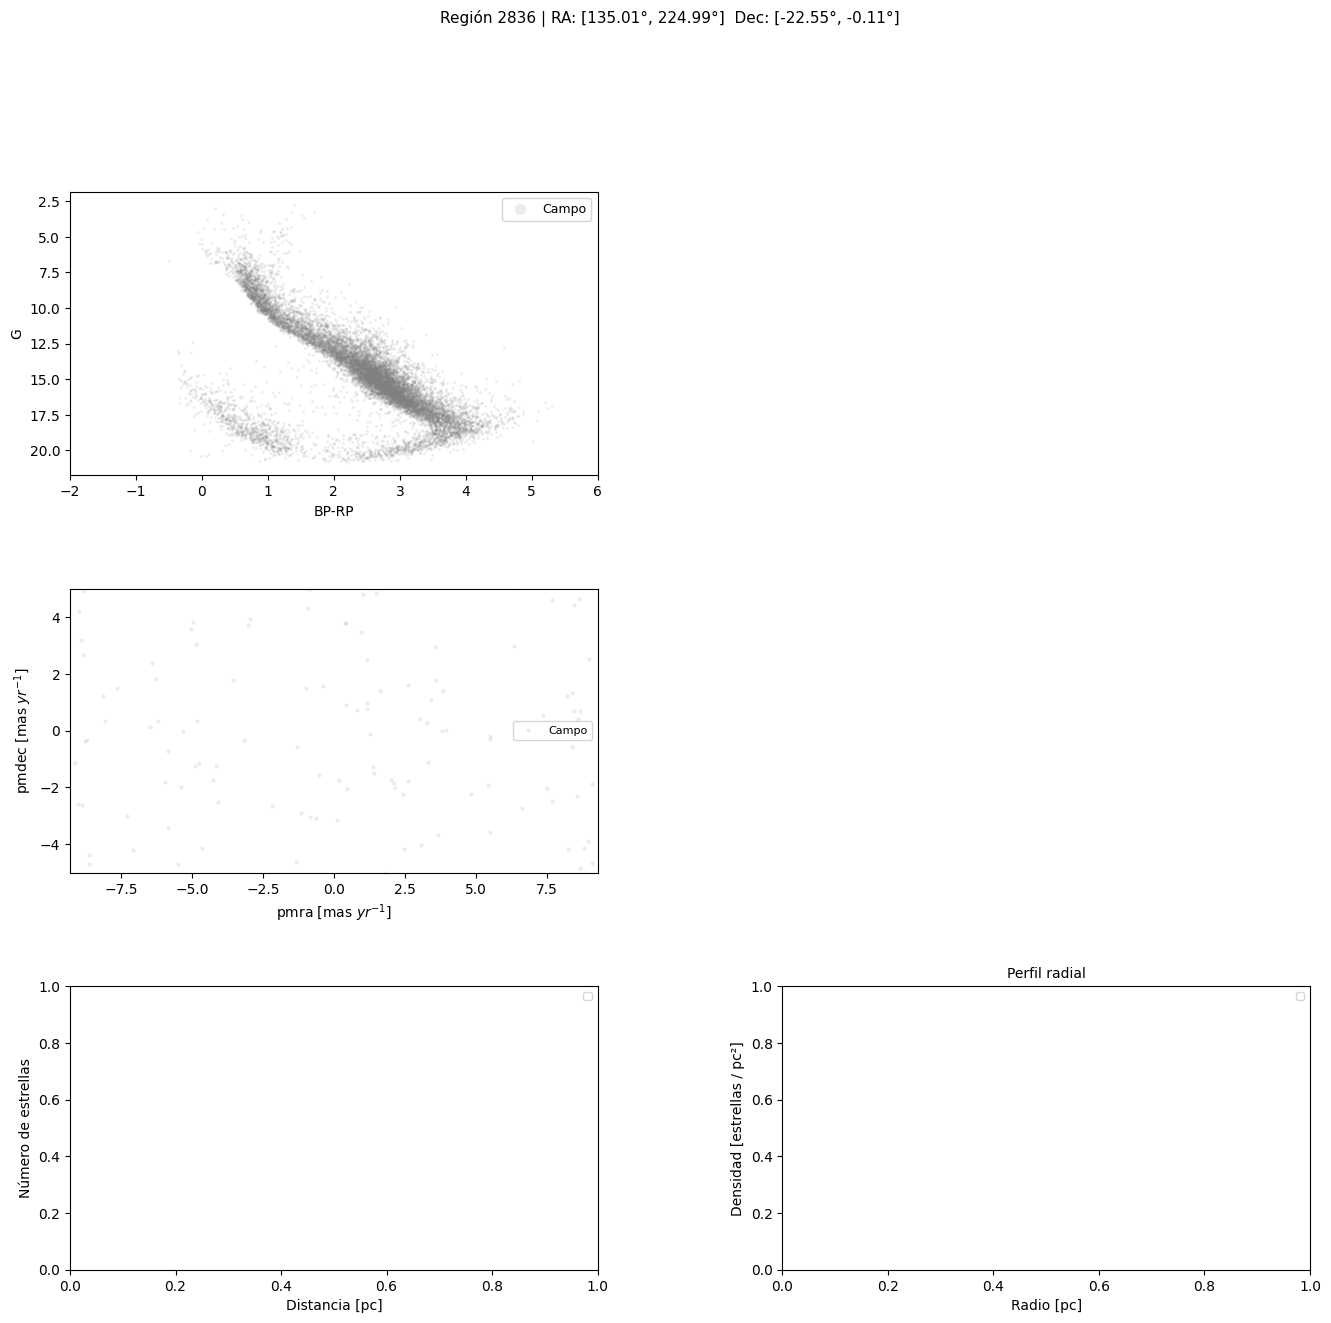

In [9]:
df = df_test
cell_id = "2836"
ra_min, ra_max   = df['ra'].min(),  df['ra'].max()
dec_min, dec_max = df['dec'].min(), df['dec'].max()
print(f"  RA:  [{ra_min:.4f}°, {ra_max:.4f}°]  |  Dec: [{dec_min:.4f}°, {dec_max:.4f}°]")

# Datos de la región, escalados
data = RobustScaler().fit_transform(df[clustering_on])

# Modelo HDBSCAN
hd = HDBSCAN(min_cluster_size=SIZE, min_samples=SAMPLES, metric='euclidean').fit(data)

# Reclasificar clusters con más de 1000 elementos como ruido
labels = hd.labels_.copy()
for lbl in set(labels):
    if lbl != -1 and np.sum(labels == lbl) > 1000:
        labels[labels == lbl] = -1

df['label_hb'] = labels
unique_labels = set(labels)
num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

# ── Asignar cluster_id global ────────────────────────────────────────
df['cluster_id'] = df['label_hb'].apply(lambda l: make_cluster_id(cell_id, l))
# Mapeo local → global para las gráficas
id_map = {lbl: make_cluster_id(cell_id, lbl) for lbl in unique_labels}

# Escribir de vuelta a df_full
if 'cluster_id' not in df_full.columns:
    df_full['cluster_id'] = None
df_full.loc[df.index, 'cluster_id'] = df['cluster_id']

if num_clusters < 2:
    if num_clusters == 0:
        print(f"  [SKIP] Región {cell_id}: ningún cluster encontrado.")
        
    print(f"  [INFO] Región {cell_id}: {num_clusters} cluster(s) válido(s) — graficando sin silueta.")
    showGraphics(df, unique_labels, id_map, with_silhouette=False, cell_id=cell_id)

else:
    # Siluetas
    mask = labels != -1
    sil_values = np.full(len(labels), np.nan)
    sil_values[mask] = silhouette_samples(data[mask], labels[mask])

    sil_per_cluster = pd.Series(np.nan, index=df.index)
    for lbl in unique_labels:
        if lbl != -1:
            cond = df['label_hb'] == lbl
            sil_per_cluster[cond] = np.nanmean(sil_values[cond.values])

    df['cluster_silhouette'] = sil_per_cluster
    df['silhouette'] = sil_values

    # Mostrar gráficas
    showGraphics(df, unique_labels, id_map, with_silhouette=True, cell_id=cell_id)

In [ ]:
fig, ax = plt.subplots(figsize=(18, 10))

# ── Campo (no asignado o ruido) ──────────────────────────────────────────────
noise = df_full['cluster_id'].isna() | df_full['cluster_id'].str.endswith('_999')
ax.scatter(
    df_full.loc[noise, 'ra'],
    df_full.loc[noise, 'dec'],
    s=0.5, color='lightgray', alpha=0.2, label='Campo / Ruido', rasterized=True
)

# ── Clusters ─────────────────────────────────────────────────────────────────
cluster_ids = sorted(
    df_full.loc[~noise & df_full['cluster_id'].notna(), 'cluster_id'].unique()
)
cmap = plt.cm.tab20
cluster_colors = {cid: cmap(i % 20) for i, cid in enumerate(cluster_ids)}

for cid in cluster_ids:
    mask = df_full['cluster_id'] == cid
    ax.scatter(
        df_full.loc[mask, 'ra'],
        df_full.loc[mask, 'dec'],
        s=4, color=cluster_colors[cid], alpha=0.8, label=cid, rasterized=True
    )

# ── Demarcación de regiones ───────────────────────────────────────────────────
for cell_id in sorted(df_full['cell_id'].unique()):
    cell_df = df_full[df_full['cell_id'] == cell_id]
    ra_min,  ra_max  = cell_df['ra'].min(),  cell_df['ra'].max()
    dec_min, dec_max = cell_df['dec'].min(), cell_df['dec'].max()

    rect = plt.Rectangle(
        (ra_min, dec_min),
        ra_max - ra_min,
        dec_max - dec_min,
        linewidth=0.8, edgecolor='black', facecolor='none', linestyle='--', alpha=0.5
    )
    ax.add_patch(rect)
    ax.text(
        ra_min + (ra_max - ra_min) * 0.02,
        dec_max - (dec_max - dec_min) * 0.08,
        f"{int(cell_id):02d}",
        fontsize=7, color='black', alpha=0.6
    )

# ── Formato ───────────────────────────────────────────────────────────────────
ax.set_xlabel("RA [°]")
ax.set_ylabel("Dec [°]")
ax.set_title("Clusters detectados por región")
ax.invert_xaxis()   # RA crece hacia la izquierda por convención astronómica

# Legend fuera, solo para clusters (excluye campo/ruido del conteo principal)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, labels,
    markerscale=3, fontsize=7,
    loc='upper left', bbox_to_anchor=(1.01, 1),
    borderaxespad=0, ncol=max(1, len(cluster_ids) // 25 + 1)
)

plt.tight_layout()
plt.show()

In [ ]:
# ── Resumen global ────────────────────────────────────────────────────────────
all_clusters = df_full.loc[
    df_full['cluster_id'].notna() & ~df_full['cluster_id'].str.endswith('_999'),
    'cluster_id'
].unique()

regions_with_clusters = set(cid.split('_')[0] for cid in all_clusters)

total_clusters  = len(all_clusters)
total_regions   = len(regions_with_clusters)
avg_per_region  = total_clusters / total_regions if total_regions > 0 else 0

print(f"Total de clusters hallados:        {total_clusters}")
print(f"Regiones con al menos 1 cluster:   {total_regions}")
print(f"Promedio de clusters por región:   {avg_per_region:.2f}")